In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#img = argv.image
img = cv2.imread('.\\img.png')
tpl_char = cv2.imdecode(np.fromfile("..\\assets\\resource\\image\\连结印记.png", dtype=np.uint8),cv2.IMREAD_COLOR)
tpl_event = cv2.imdecode(np.fromfile("..\\assets\\resource\\image\\EVENT.png", dtype=np.uint8),cv2.IMREAD_COLOR)
tpl_normal = cv2.imdecode(np.fromfile("..\\assets\\resource\\image\\战斗-普通.png", dtype=np.uint8),cv2.IMREAD_COLOR)

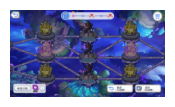

In [3]:
tmp_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(2, 2))  # 设置显示窗口的大小（英寸）
plt.imshow(tmp_img)
plt.axis('off')              # 隐藏坐标轴（如果想看像素坐标，可以把这行注释掉）
plt.show()                   # 在 Jupyter 单元格中渲染图片

In [4]:
def find_nodes(template, type_name, threshold=0.75):
    if template is None:
        print(f"❌ 错误：未能成功加载模板图片 -> {type_name}")
        return
    h, w = template.shape[:2]
    # 执行模板匹配
    res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= threshold)
    for pt in zip(*loc[::-1]):  # pt 是匹配到的左上角坐标 (x, y)
        center_x = pt[0] + w // 2
        center_y = pt[1] + h // 2
        matched_col = -1
        matched_row = -1
        # 匹配所属列
        for col_idx, (min_x, max_x) in enumerate(COLUMNS_X):
            if min_x <= center_x <= max_x:
                matched_col = col_idx
                break
        # 匹配所属行
        for row_idx, (min_y, max_y) in enumerate(ROWS_Y):
            if min_y <= center_y <= max_y:
                matched_row = row_idx
                break
        # 如果成功定位到网格，且该格子目前没有被占用，则写入数据
        if matched_col != -1 and matched_row != -1:
            if grid_data[matched_col][matched_row]["type"] == "EMPTY":
                grid_data[matched_col][matched_row] = {
                    "type": type_name,
                    "pos": (center_x, center_y)
                }

In [5]:
COLUMNS_X = [
    (380, 500),
    (900, 1050),
    (1400, 1550)
]
ROWS_Y = [
    (200, 380),
    (500, 650),
    (750, 920)
]
# 初始化 3x3 网格数据结构
grid_data = [[{"type": "EMPTY", "pos": None} for _ in range(3)] for _ in range(3)]

# 3. 依次识别三种节点（对应你的新变量名）
find_nodes(tpl_char, "CHAR")       # 连结印记 -> 粉色节点
find_nodes(tpl_event, "EVENT")     # EVENT -> 事件节点
find_nodes(tpl_normal, "NORMAL")  # 战斗-普通 -> 怪物节点
# 4. 打印当前图像转换出的数据
print("--- 1080P 节点数字化结果 ---")
for c in range(3):
    for r in range(3):
        node = grid_data[c][r]
        print(f"列 {c} 行 {r} -> 类型: {node['type']}, 核心点击坐标: {node['pos']}")

--- 1080P 节点数字化结果 ---
列 0 行 0 -> 类型: EVENT, 核心点击坐标: (np.int64(443), np.int64(285))
列 0 行 1 -> 类型: CHAR, 核心点击坐标: (np.int64(438), np.int64(590))
列 0 行 2 -> 类型: EVENT, 核心点击坐标: (np.int64(443), np.int64(810))
列 1 行 0 -> 类型: NORMAL, 核心点击坐标: (np.int64(969), np.int64(329))
列 1 行 1 -> 类型: NORMAL, 核心点击坐标: (np.int64(968), np.int64(592))
列 1 行 2 -> 类型: NORMAL, 核心点击坐标: (np.int64(969), np.int64(854))
列 2 行 0 -> 类型: EVENT, 核心点击坐标: (np.int64(1493), np.int64(285))
列 2 行 1 -> 类型: CHAR, 核心点击坐标: (np.int64(1489), np.int64(590))
列 2 行 2 -> 类型: EVENT, 核心点击坐标: (np.int64(1493), np.int64(810))


In [53]:
def is_line_existing(img, pos_A, pos_B, row_curr, row_next, tpl_path, threshold=0.82):
    if pos_A is None or pos_B is None:
        return False
        
    tpl_rgba = cv2.imdecode(np.fromfile(tpl_path, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
    tpl_bgr = tpl_rgba[:, :, :3]
    tpl_alpha = tpl_rgba[:, :, 3]

    x1, y1 = int(pos_A[0]), int(pos_A[1])
    x2, y2 = int(pos_B[0]), int(pos_B[1])
    dy = y2 - y1
    
    # 🎯 🔥【神级修正】直接用行索引判断。同行即水平，异行即斜线！
    is_horizontal = (row_curr == row_next)
    
    if is_horizontal:
        # 🟢 【水平线分支】: 保持原汁原味，不拉伸，不旋转！
        current_tpl = tpl_bgr
        current_mask = tpl_alpha
    else:
        # 🔵 【斜线分支】: 拉伸至固定 325 像素，并顺/逆时针旋转 31°
        fixed_width = 325 
        orig_h = tpl_bgr.shape[0]
        tpl_bgr_resized = cv2.resize(tpl_bgr, (fixed_width, orig_h), interpolation=cv2.INTER_LINEAR)
        tpl_alpha_resized = cv2.resize(tpl_alpha, (fixed_width, orig_h), interpolation=cv2.INTER_LINEAR)
        
        fixed_angle = -31.0 if dy > 0 else 31.0
        
        (h, w) = tpl_bgr_resized.shape[:2]
        cx, cy = w // 2, h // 2
        M = cv2.getRotationMatrix2D((cx, cy), fixed_angle, 1.0)
        cos, sin = np.abs(M[0, 0]), np.abs(M[0, 1])
        nW = int((h * sin) + (w * cos))
        nH = int((h * cos) + (w * sin))
        M[0, 2] += (nW / 2) - cx
        M[1, 2] += (nH / 2) - cy
        
        current_tpl = cv2.warpAffine(tpl_bgr_resized, M, (nW, nH), flags=cv2.INTER_LINEAR)
        current_mask = cv2.warpAffine(tpl_alpha_resized, M, (nW, nH), flags=cv2.INTER_NEAREST, borderValue=0)
    
    # 切出安全区
    mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
    roi = img[max(0, mid_y-140):min(img.shape[0], mid_y+140), 
              max(0, mid_x-190):min(img.shape[1], mid_x+190)]
              
    if roi.shape[0] < current_tpl.shape[0] or roi.shape[1] < current_tpl.shape[1]:
        return False 
        
    res = cv2.matchTemplate(roi, current_tpl, cv2.TM_CCOEFF_NORMED, mask=current_mask)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    
    # 既然有 Mask 且排除了分支干扰，真线全部在 0.9 以上，统一 0.82 阈值坚不可摧！
    return max_val > threshold

In [55]:
# === 🎯 最终全网轰炸主循环 ===
print("=== 🏆 终极完全体 V4·索引分流大对账 ===")
tpl_path = "..\\assets\\resource\\image\\道路.png"

for col in range(2):
    for row_curr in range(3):
        node_start = grid_data[col][row_curr]
        if node_start is None: continue
            
        for row_next in range(3):
            node_end = grid_data[col+1][row_next]
            if node_end is None: continue
                
            # 传入 row_curr 和 row_next 作为坚实的路由判定依据
            if is_line_existing(img, node_start["pos"], node_end["pos"], row_curr, row_next, tpl_path, threshold=0.82):
                print(f"🔗 [成功捕获] 列{col}行{row_curr} ──> 列{col+1}行{row_next}")

=== 🏆 终极完全体 V4·索引分流大对账 ===
🔗 [成功捕获] 列0行0 ──> 列1行0
🔗 [成功捕获] 列0行0 ──> 列1行1
🔗 [成功捕获] 列0行1 ──> 列1行1
🔗 [成功捕获] 列0行1 ──> 列1行2
🔗 [成功捕获] 列0行2 ──> 列1行2
🔗 [成功捕获] 列1行0 ──> 列2行0
🔗 [成功捕获] 列1行1 ──> 列2行0
🔗 [成功捕获] 列1行1 ──> 列2行1
🔗 [成功捕获] 列1行1 ──> 列2行2
🔗 [成功捕获] 列1行2 ──> 列2行2


In [56]:
class GameGraph:
    def __init__(self):
        # 存储节点属性，格式：{"0_0": "CHAR", "0_1": "NORMAL", ...}
        self.nodes = {}
        # 存储邻接表（拓扑通路），格式：{"0_0": ["1_0", "1_1"], ...}
        self.adjacency_list = {}
    
    def add_node(self, col, row, node_type):
        """添加节点及其类型"""
        node_id = f"{col}_{row}"
        self.nodes[node_id] = node_type
        if node_id not in self.adjacency_list:
            self.adjacency_list[node_id] = []
            
    def add_edge(self, from_col, from_row, to_col, to_row):
        """添加一条有向边（只能从左往右）"""
        from_id = f"{from_col}_{from_row}"
        to_id = f"{to_col}_{to_row}"
        if from_id in self.adjacency_list:
            if to_id not in self.adjacency_list[from_id]:
                self.adjacency_list[from_id].append(to_id)
                
    def get_type(self, node_id):
        """获取某个坐标的节点类型"""
        return self.nodes.get(node_id, "UNKNOWN")

    def show_graph(self):
        """直观打印当前图的完整结构"""
        print("=== 📊 关卡数据图拓扑矩阵 ===")
        for node_id, edges in self.adjacency_list.items():
            node_type = self.get_type(node_id)
            edge_strs = [f"{target}({self.get_type(target)})" for target in edges]
            print(f"📍 节点 {node_id} [{node_type}] ──> 可达: {edge_strs}")

In [58]:
# 1. 实例化我们的数据图
level_graph = GameGraph()

tpl_path = "..\\assets\\resource\\image\\道路.png"

# 2. 第一步：先把所有存在的节点和它们的类型灌进去
# 假设你的 grid_data 里已经存了节点类型，比如 node["type"] = 'CHAR'
for col in range(3): # 遍历所有 3 列
    for row in range(3):
        node = grid_data[col][row]
        if node is None: continue
        
        # 灌入节点类型（这里我用 node.get("type", "NORMAL") 示意，请换成你实际的类型字段）
        level_graph.add_node(col, row, node.get("type", "NORMAL"))

# 3. 第二步：遍历连线，灌入边（Edge）关系
for col in range(2): # 前两列向后连线
    for row_curr in range(3):
        node_start = grid_data[col][row_curr]
        if node_start is None: continue
            
        for row_next in range(3):
            node_end = grid_data[col+1][row_next]
            if node_end is None: continue
                
            # 利用我们刚刚调校完美的 V4 核心判定器
            if is_line_existing(img, node_start["pos"], node_end["pos"], row_curr, row_next, tpl_path):
                # 图像识别成功，直接在图对象里连线！
                level_graph.add_edge(col, row_curr, col+1, row_next)

# 4. 🖨️ 打印大功告成的数据图
level_graph.show_graph()

=== 📊 关卡数据图拓扑矩阵 ===
📍 节点 0_0 [EVENT] ──> 可达: ['1_0(NORMAL)', '1_1(NORMAL)']
📍 节点 0_1 [CHAR] ──> 可达: ['1_1(NORMAL)', '1_2(NORMAL)']
📍 节点 0_2 [EVENT] ──> 可达: ['1_2(NORMAL)']
📍 节点 1_0 [NORMAL] ──> 可达: ['2_0(EVENT)']
📍 节点 1_1 [NORMAL] ──> 可达: ['2_0(EVENT)', '2_1(CHAR)', '2_2(EVENT)']
📍 节点 1_2 [NORMAL] ──> 可达: ['2_2(EVENT)']
📍 节点 2_0 [EVENT] ──> 可达: []
📍 节点 2_1 [CHAR] ──> 可达: []
📍 节点 2_2 [EVENT] ──> 可达: []


In [59]:
def find_all_graph_paths(graph, current_node, end_type, current_path=[]):
    """
    基于 GameGraph 对象的拓扑寻路核心（递归回溯）
    """
    current_path = current_path + [current_node]
    current_type = graph.get_type(current_node)
    
    # 🎯 终点判定：如果当前节点类型正好是我们要找的终点类型，且路径长度大于 1（防止原地打转）
    if current_type == end_type and len(current_path) > 1:
        return [current_path]
        
    # 如果当前节点没有后续连线了，说明此路不通
    neighbors = graph.adjacency_list.get(current_node, [])
    if not neighbors:
        return []
        
    paths = []
    # 严格从左往右遍历邻居
    for next_node in neighbors:
        if next_node not in current_path:
            # 递归探索
            new_paths = find_all_graph_paths(graph, next_node, end_type, current_path)
            for p in new_paths:
                paths.append(p)
    return paths

def plan_routes_by_type(graph, start_type="CHAR", end_type="CHAR"):
    """
    高级路由规划：从指定的 start_type 到 end_type 的所有最优通路
    """
    # 1. 自动在图中检索出所有符合条件的起点节点
    start_nodes = [node_id for node_id, t_type in graph.nodes.items() if t_type == start_type]
    
    if not start_nodes:
        print(f"⚠️  图中未发现类型为 [{start_type}] 的起点节点。")
        return
        
    print(f"🚀 [网格扫描] 锁定起点节点: {start_nodes}")
    print(f"🎯 [目标锁定] 终点类型: [{end_type}]\n")
    
    total_routes_found = 0
    
    # 2. 从每一个潜在起点出发进行路径推演
    for s_node in start_nodes:
        valid_paths = find_all_graph_paths(graph, s_node, end_type)
        
        if not valid_paths:
            continue
            
        for path in valid_paths:
            total_routes_found += 1
            # 3. 统计这条路线的节点类型链
            type_chain = [graph.get_type(n) for n in path]
            
            # 4. 智能化计算旅途成分（比如包含多少个事件，多少个普通格）
            events_count = type_chain.count("EVENT")
            normals_count = type_chain.count("NORMAL")
            chars_count = type_chain.count("CHAR")
            
            print(f"🛣️  【可行方案 {total_routes_found}】")
            print(f"  🧭 节点走位: {' ──> '.join(path)}")
            print(f"  🎨 属性步进: {' ──> '.join([f'{n}({graph.get_type(n)})' for n in path])}")
            print(f"  📊 旅途成分: CHAR × {chars_count} | EVENT × {events_count} | NORMAL × {normals_count}")
            print("-" * 65)
            
    if total_routes_found == 0:
        print(f"🧱 规划失败：全图未发现任何能从 [{start_type}] 走到 [{end_type}] 的合规有向通路。")

In [60]:
# 假设你想看从 CHAR 到 CHAR 的所有走法
plan_routes_by_type(level_graph, start_type="CHAR", end_type="CHAR")

🚀 [网格扫描] 锁定起点节点: ['0_1', '2_1']
🎯 [目标锁定] 终点类型: [CHAR]

🛣️  【可行方案 1】
  🧭 节点走位: 0_1 ──> 1_1 ──> 2_1
  🎨 属性步进: 0_1(CHAR) ──> 1_1(NORMAL) ──> 2_1(CHAR)
  📊 旅途成分: CHAR × 2 | EVENT × 0 | NORMAL × 1
-----------------------------------------------------------------
